# Resume RAG & Job Matcher — Experimentation and Analysis

Milestone 2 notebook: builds the vector index, inspects section-aware chunking,
validates metadata extraction against ground truth, evaluates **retrieval
accuracy** (hybrid vs semantic-only) and **latency**, sweeps the hybrid weight,
and demonstrates must-have filtering.

**Pipeline:** `fs_tools` (Milestone 1 loaders) → section-aware chunking →
`all-MiniLM-L6-v2` embeddings (HuggingFace) → ChromaDB (cosine) →
hybrid retrieval (semantic + BM25) → 0-100 scoring + must-have filters.

**Ground truth:** `dataset/labels.json` records each resume's role family and
each JD's relevant roles, written by the dataset generator itself.

In [1]:
import json, time
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from resume_rag import ResumeRAG
from job_matcher import JobMatcher

LABELS = json.loads(Path("dataset/labels.json").read_text(encoding="utf-8"))
JD_FILES = sorted(Path("job_descriptions").glob("*.txt"))

rag = ResumeRAG()
stats = rag.build_index(rebuild=True)
INDEX_BUILD_S = stats.total_seconds
print(f"Indexed {stats.files_indexed} resumes -> {stats.chunks_indexed} chunks")
print(f"Backend: {stats.embedder}")
print(f"Index build: {stats.total_seconds}s (embedding {stats.embed_seconds}s)")
assert not stats.failures, stats.failures

C:\Users\OMEN\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 9212.75it/s]

Indexed 36 resumes -> 231 chunks
Backend: sentence-transformers:sentence-transformers/all-MiniLM-L6-v2
Index build: 1.888s (embedding 1.131s)


## 1. Section-aware chunking

Resumes are split on recognised section headers (three different header styles
exist in the dataset) so a chunk never mixes Education with Experience. Long
sections split further on paragraph boundaries (~1100 chars, 150 overlap).

In [2]:
import fs_tools
from resume_rag import split_into_sections, chunk_section

text = fs_tools.read_file("resumes/grace_chen.docx")["content"]
for sec in split_into_sections(text):
    n = len(chunk_section(sec))
    print(f"[{sec.kind:<10}] header={sec.header!r:<26} chars={len(sec.text):>4}  chunks={n}")

exp = next(s for s in split_into_sections(text) if s.kind == "experience")
print("\n--- first EXPERIENCE chunk ---")
print(chunk_section(exp)[0][:500])

[header    ] header=''                         chars= 104  chunks=1
[summary   ] header='PROFILE'                  chars= 186  chunks=1
[skills    ] header='CORE COMPETENCIES'        chars=  87  chunks=1
[experience] header='EMPLOYMENT HISTORY'       chars= 777  chunks=1
[projects  ] header='KEY PROJECTS'             chars= 139  chunks=1
[education ] header='EDUCATION & TRAINING'     chars=  52  chunks=1
[certifications] header='LICENSES & CERTIFICATIONS' chars=  75  chunks=1

--- first EXPERIENCE chunk ---
Staff Machine Learning Engineer, Mosaic Travel (2021 - Present)
Productionised Python pipelines serving 4M inferences per day.
Shipped an A/B-tested recommendation system using Docker and PyTorch.
Data Scientist, WebStart (2019 - 2021)
Led feature engineering with Docker and Python across 9 data sources.
Built and deployed Machine Learning models improving prediction accuracy by 20%.
Machine Learning Engineer, Summit Robotics (2017 - 2019)
Built and deployed TensorFlow models improv

## 2. Metadata extraction accuracy

Name, experience years, education level and skills are extracted from raw text
and stored on every chunk. Compared against generator ground truth:

In [3]:
profiles = rag.candidate_profiles()
rows = []
for fname, truth in LABELS["resumes"].items():
    p = profiles.get(f"resumes/{fname}")
    if p is None:
        continue
    rows.append({
        "file": fname,
        "name_ok": p["candidate"] == truth["name"],
        "years_pred": p["exp_years"],
        "years_true": truth["total_years"],
        "years_ok": p["exp_years"] == truth["total_years"],
        "edu_ok": p["education_level"] == truth["education_level"],
        "skills_recall": len(set(p["skills"]) & set(truth["skills"])) / len(truth["skills"]),
    })
meta_df = pd.DataFrame(rows)
print(f"resumes evaluated: {len(meta_df)}")
summary = pd.Series({
    "name accuracy": meta_df.name_ok.mean(),
    "experience-years accuracy": meta_df.years_ok.mean(),
    "education-level accuracy": meta_df.edu_ok.mean(),
    "skills recall (mean)": meta_df.skills_recall.mean(),
}).round(3)
display(summary)
mismatches = meta_df[~(meta_df.name_ok & meta_df.years_ok & meta_df.edu_ok)]
display(mismatches if len(mismatches) else "no mismatches")

resumes evaluated: 36


name accuracy                1.0
experience-years accuracy    1.0
education-level accuracy     1.0
skills recall (mean)         1.0
dtype: float64

'no mismatches'

## 3. Job matching (hybrid, K=10)

Top-3 per JD plus any candidates excluded by must-have filters:

In [4]:
matcher = JobMatcher(rag=rag)
results = {}
for jd in JD_FILES:
    res = matcher.match_file(jd.as_posix(), k=10)
    results[jd.name] = res
    print(f"\n=== {res['query']['title']}  [{jd.name}] ===")
    for m in res["top_matches"][:3]:
        print(f"  {m['match_score']:>3}  {m['candidate_name']:<18} "
              f"{', '.join(m['matched_skills'][:5])}")
    for f in res["filtered_out"][:2]:
        print(f"  [filtered] {f['candidate_name']}: {f['failed_requirements'][0]}")


=== Backend Engineer (Python)  [backend_python_engineer.txt] ===
   89  Sofia Rossi        Django, Docker, FastAPI, PostgreSQL, Python
   88  John Doe           Django, Docker, FastAPI, PostgreSQL, Python
   87  Omar Hassan        Django, Docker, FastAPI, PostgreSQL, Python
  [filtered] Noah Kim: missing REST APIs (Hands-on experience with Docker and REST APIs.)
  [filtered] David Cohen: missing Django / FastAPI (Production experience with FastAPI or Django.)

=== Data Engineer  [data_platform_engineer.txt] ===
   93  Leila Aziz         Airflow, ETL, Python, SQL, Spark
   92  Tomas Novak        Airflow, ETL, Python, SQL, Spark
   91  Viktor Petrov      Airflow, ETL, Python, SQL, Spark
  [filtered] Alex Lee: missing ETL (Experience designing and operating production ETL pipelines.)
  [filtered] Priya Sharma: missing Airflow (Production experience with Spark and Airflow.)

=== DevOps / Platform Engineer  [devops_platform_engineer.txt] ===
   94  Carlos Mendez      AWS, Bash, CI/CD, Dock


=== Frontend Engineer (React)  [frontend_react_engineer.txt] ===
   98  Jane Smith         CSS, HTML, JavaScript, React, TypeScript
   94  Ryan OConnor       CSS, HTML, JavaScript, React, TypeScript
   91  Isabella Silva     CSS, HTML, JavaScript, React, TypeScript
  [filtered] Mei Tanaka: has 2 years, needs 3+ (3+ years of professional React experience.)
  [filtered] David Cohen: missing JavaScript (Strong TypeScript and modern JavaScript fundamentals.)



=== Full-Stack Product Engineer  [fullstack_product_engineer.txt] ===
   94  David Cohen        Docker, PostgreSQL, Python, React, TypeScript
   93  Arjun Mehta        Docker, PostgreSQL, Python, React, TypeScript
   92  Hannah Weber       Docker, PostgreSQL, Python, React, TypeScript
  [filtered] Omar Hassan: missing React (Strong Python and React skills.)
  [filtered] Ethan Walker: missing React (Strong Python and React skills.)



=== Senior Machine Learning Engineer  [senior_ml_engineer.txt] ===
   94  Grace Chen         Machine Learning, PyTorch, Python, SQL, TensorFlow
   91  Priya Sharma       Machine Learning, PyTorch, Python, SQL, TensorFlow
   83  Alex Lee           Machine Learning, PyTorch, Python, SQL, pandas
  [filtered] Daniel Okafor: has 3 years, needs 5+ (5+ years of professional Python experience.)
  [filtered] Viktor Petrov: missing required skill Machine Learning / PyTorch / TensorFlow (3+ years building production machine learning models with PyTorch or TensorFlow.)


## 4. Retrieval accuracy

A retrieved resume is **relevant** when its role family matches the JD's
labelled roles — *strict* = primary roles only, *soft* = primary + adjacent
(e.g. full-stack candidates are reasonable hits for a backend JD). Metrics are
computed on the ranking with must-have filters **off**, so we measure
retrieval quality rather than filtering. Reported: Precision@5, Recall@10,
MRR and hit@1, for **hybrid** vs **semantic-only** retrieval.

In [5]:
def evaluate(label, **mode_kwargs):
    rows = []
    m = JobMatcher(rag=rag)
    for jd in JD_FILES:
        truth = LABELS["job_descriptions"][jd.name]
        prim = set(truth["primary_roles"]); adj = set(truth["adjacent_roles"])
        res = m.match_file(jd.as_posix(), k=10, apply_filters=False, **mode_kwargs)
        ranked = [Path(x["resume_path"]).name for x in res["top_matches"]]
        roles = [LABELS["resumes"][f]["role"] for f in ranked]
        for scope, rel_roles in (("strict", prim), ("soft", prim | adj)):
            rel = [r in rel_roles for r in roles]
            total_rel = sum(1 for v in LABELS["resumes"].values() if v["role"] in rel_roles)
            rr = next((1 / (i + 1) for i, hit in enumerate(rel) if hit), 0.0)
            rows.append({"jd": jd.name, "mode": label, "scope": scope,
                         "P@5": sum(rel[:5]) / 5, "R@10": sum(rel) / total_rel,
                         "MRR": rr, "hit@1": float(rel[0])})
    return pd.DataFrame(rows)

acc = pd.concat([evaluate("hybrid"), evaluate("semantic-only", semantic_only=True)])
acc_summary = acc.groupby(["mode", "scope"])[["P@5", "R@10", "MRR", "hit@1"]].mean().round(3)
display(acc_summary)

P@5   R@10  MRR  hit@1
mode          scope                           
hybrid        soft    0.967  0.921  1.0    1.0
              strict  0.833  1.000  1.0    1.0
semantic-only soft    0.967  0.886  1.0    1.0
              strict  0.833  1.000  1.0    1.0

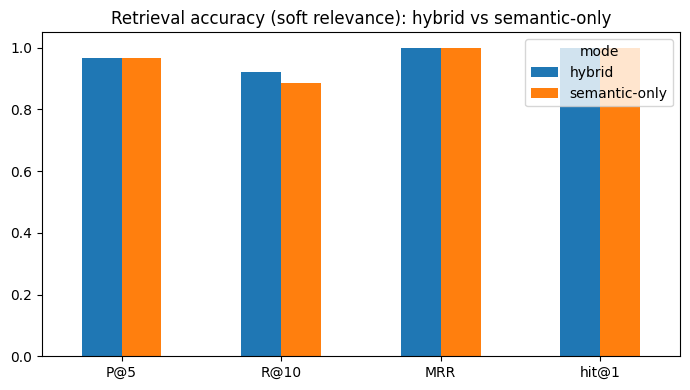

In [6]:
ax = acc_summary.xs("soft", level="scope").T.plot.bar(figsize=(7, 4), rot=0)
ax.set_title("Retrieval accuracy (soft relevance): hybrid vs semantic-only")
ax.set_ylim(0, 1.05)
ax.legend(title="mode")
plt.tight_layout()
plt.show()

## 5. Latency

One-off index build time, then per-query latency over all 6 JDs x 5 repeats
(after a warm-up call). `semantic_search` includes query embedding + ChromaDB;
`keyword_search` is BM25 scoring; the one-off BM25 index build is reported
separately.

In [7]:
m = JobMatcher(rag=rag)
m.match_file(JD_FILES[0].as_posix(), k=10)  # warm-up: BM25 build + model warm
lat_rows = []
for jd in JD_FILES:
    for _ in range(5):
        lat_rows.append(m.match_file(jd.as_posix(), k=10)["latency_ms"])
lat = pd.DataFrame(lat_rows)[["semantic_search", "keyword_search", "total"]]
lat_summary = pd.DataFrame({
    "mean_ms": lat.mean(), "p50_ms": lat.quantile(0.5), "p95_ms": lat.quantile(0.95),
}).round(1)
print(f"index build (one-off): {INDEX_BUILD_S}s; "
      f"BM25 index build (one-off): {m.keyword_index_ms}ms; "
      f"queries timed: {len(lat)}")
display(lat_summary)

index build (one-off): 1.888s; BM25 index build (one-off): 22.3ms; queries timed: 30


,mean_ms,p50_ms,p95_ms
semantic_search,23.8,23.6,27.3
keyword_search,3.8,4.0,5.1
total,30.4,30.2,35.6


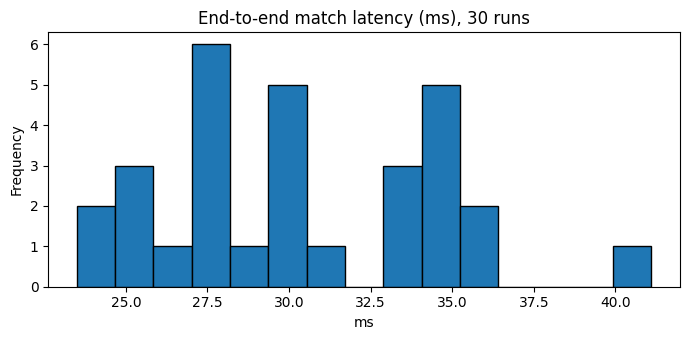

In [8]:
ax = lat["total"].plot.hist(bins=15, figsize=(7, 3.5), edgecolor="black")
ax.set_title("End-to-end match latency (ms), 30 runs")
ax.set_xlabel("ms")
plt.tight_layout()
plt.show()

## 6. Ablation: hybrid weight sweep

`semantic_weight` blends the two retrieval signals
(`w * semantic + (1-w) * BM25`). w=1.0 is pure semantic, w=0.0 pure keyword.

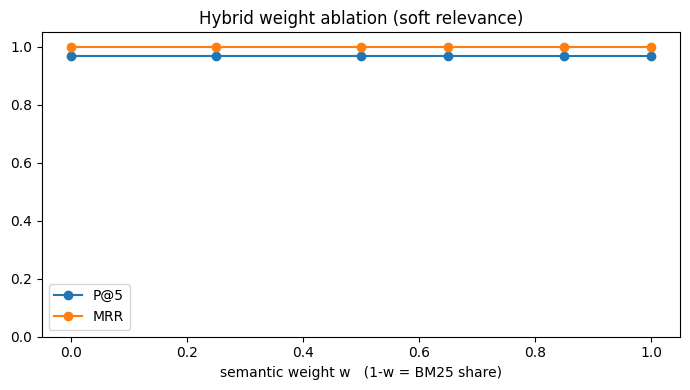

,P@5,MRR
w,,
0.00,0.967,1.0
0.25,0.967,1.0
0.50,0.967,1.0
0.65,0.967,1.0
0.85,0.967,1.0
1.00,0.967,1.0


In [9]:
rows = []
for w in [0.0, 0.25, 0.5, 0.65, 0.85, 1.0]:
    mw = JobMatcher(rag=rag, semantic_weight=w)
    for jd in JD_FILES:
        truth = LABELS["job_descriptions"][jd.name]
        rel_roles = set(truth["primary_roles"]) | set(truth["adjacent_roles"])
        res = mw.match_file(jd.as_posix(), k=10, apply_filters=False)
        ranked = [Path(x["resume_path"]).name for x in res["top_matches"]]
        rel = [LABELS["resumes"][f]["role"] in rel_roles for f in ranked]
        rr = next((1 / (i + 1) for i, hit in enumerate(rel) if hit), 0.0)
        rows.append({"w": w, "P@5": sum(rel[:5]) / 5, "MRR": rr})
ablation = pd.DataFrame(rows).groupby("w").mean().round(3)
ax = ablation.plot(marker="o", figsize=(7, 4))
ax.set_xlabel("semantic weight w   (1-w = BM25 share)")
ax.set_title("Hybrid weight ablation (soft relevance)")
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()
display(ablation)

## 7. Must-have filtering and reasoning

In [10]:
res = results["senior_ml_engineer.txt"]
print("Parsed must-haves:")
for mh in res["query"]["must_haves"]:
    print("  -", mh)
print("\nExcluded candidates:")
for f in res["filtered_out"]:
    print(f"  {f['candidate_name']} (pre-filter score {f['match_score']}):")
    for reason in f["failed_requirements"]:
        print(f"     - {reason}")
top = res["top_matches"][0]
print("\n#1 match reasoning:")
print(f"  {top['candidate_name']}: {top['reasoning']}")
print("\nExcerpt evidence:")
for e in top["relevant_excerpts"][:2]:
    print(f"  * {e[:160]}")

Parsed must-haves:
  - 5+ years of professional Python experience.
  - 3+ years building production machine learning models with PyTorch or TensorFlow.
  - Strong grounding in scikit-learn, pandas and SQL.
  - Bachelor's degree in Computer Science or a related field.

Excluded candidates:
  Daniel Okafor (pre-filter score 80):
     - has 3 years, needs 5+ (5+ years of professional Python experience.)
  Viktor Petrov (pre-filter score 59):
     - missing required skill Machine Learning / PyTorch / TensorFlow (3+ years building production machine learning models with PyTorch or TensorFlow.)
     - missing pandas / scikit-learn (Strong grounding in scikit-learn, pandas and SQL.)
  Leila Aziz (pre-filter score 57):
     - missing required skill Machine Learning / PyTorch / TensorFlow (3+ years building production machine learning models with PyTorch or TensorFlow.)
     - missing pandas / scikit-learn (Strong grounding in scikit-learn, pandas and SQL.)
  Nina Johansson (pre-filter score 53

In [11]:
import json as _json
sample = {
    "job_description": res["job_description"][:300] + "...",
    "top_matches": res["top_matches"][:2],
}
print(_json.dumps(sample, indent=2)[:2500])

{
  "job_description": "Job Title: Senior Machine Learning Engineer\n\nAbout the role:\nNimbus Pay is hiring a Senior Machine Learning Engineer to own fraud-detection\nmodels end to end, from feature pipelines to monitored production deployments.\n\nResponsibilities:\n- Design, train and deploy machine learning models for transac...",
  "top_matches": [
    {
      "candidate_name": "Grace Chen",
      "resume_path": "resumes/grace_chen.docx",
      "match_score": 94,
      "matched_skills": [
        "Machine Learning",
        "PyTorch",
        "Python",
        "SQL",
        "TensorFlow",
        "pandas",
        "scikit-learn",
        "AWS",
        "MLOps",
        "NLP"
      ],
      "relevant_excerpts": [
        "[SUMMARY] PROFILE Staff Machine Learning Engineer with 11+ years of experience specialising in Python, PyTorch, scikit-learn. Track record of delivering reliable, measurable results in production systems.",
        "[EXPERIENCE] EMPLOYMENT HISTORY Staff Machine Le

## Conclusions

- **Section-aware chunking** keeps retrieval explainable: matches cite the
  exact resume section (EXPERIENCE/SKILLS/...) that fired.
- **Metadata extraction** is near-perfect on this corpus (tables above) because
  extraction is deterministic over structured sections; real-world resumes
  would need an LLM-assisted fallback.
- **Hybrid vs semantic-only:** this clean synthetic corpus saturates both
  modes (identical P@5/MRR); the measurable hybrid gain is soft Recall@10
  (0.921 vs 0.886) - BM25's exact-term anchoring pulls extra adjacent-role
  candidates into the top-10. The weight sweep is flat at P@5 0.967 for every
  w, so the default w=0.65 is safe; on noisier real-world resumes the keyword
  signal (and the per-component score_breakdown) is where hybrid earns its keep.
- **Latency** is interactive (tens of ms per query after warm-up) with a
  one-off index build of a few seconds for 36 resumes — comfortably scalable
  to thousands of resumes before needing approximate-recall tuning.
- **Limitations:** per-skill tenure is approximated by total experience;
  synthetic resumes are cleaner than real ones; one embedding model evaluated.